In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import ADASYN
from imblearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, roc_auc_score, recall_score, precision_score,
                             make_scorer)
from imblearn.ensemble import BalancedRandomForestClassifier, BalancedBaggingClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier,VotingClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from imblearn.under_sampling import EditedNearestNeighbours
from imblearn.combine import SMOTETomek ,SMOTEENN
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import classification_report
from aif360.algorithms.preprocessing import Reweighing
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import ClassificationMetric

In [5]:
df=pd.read_csv('/content/drive/MyDrive/python-20260209T035007Z-1-001/python/cleanedDataset2.csv')
df.shape

(1470, 11)

In [ ]:
df.head()

,Age,BusinessTravel,DistanceFromHome,Education,Gender,JobInvolvement,MaritalStatus,PerformanceRating,TotalWorkingYears,TrainingTimesLastYear,Should_hire
0,41,2,1,2,0,3,2,3,8,0,0
1,49,1,8,1,1,2,1,4,10,3,1
2,37,2,2,2,1,2,2,3,7,3,0
3,33,1,3,4,0,3,1,3,8,3,1
4,27,2,2,1,1,3,1,3,6,3,1


# **balancing data**

/tmp/ipython-input-1711258326.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x=colonne, palette=['#1f77b4', '#ff7f0e'])


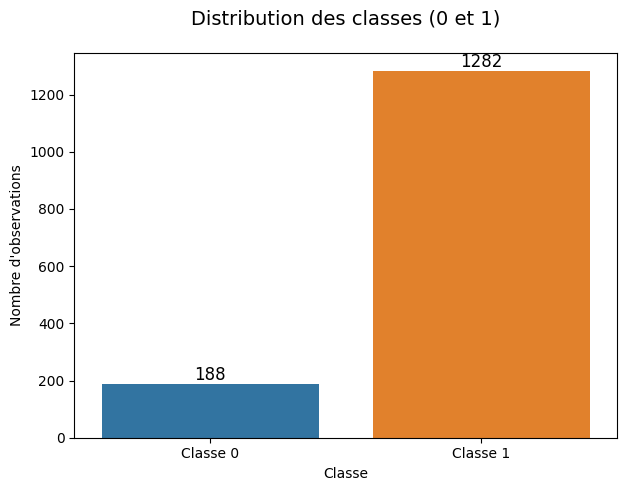

In [ ]:
def afficher_graph(df, colonne):
    plt.figure(figsize=(7, 5))
    ax = sns.countplot(data=df, x=colonne, palette=['#1f77b4', '#ff7f0e'])

    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=12)

    plt.title('Distribution des classes (0 et 1)', fontsize=14, pad=20)
    plt.xlabel('Classe')
    plt.ylabel('Nombre d\'observations')
    plt.xticks([0, 1], ['Classe 0', 'Classe 1'])
    plt.show()

afficher_graph(df, 'Should_hire')

In [ ]:
y = df['Should_hire']
X = df.drop('Should_hire', axis=1)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
# SMOTETomek
smote_tomek = SMOTETomek(random_state=42)
X_tomek, y_tomek = smote_tomek.fit_resample(X, y)
print(f"Taille avant : {y_train.value_counts()}")
X_train_res, y_train_res = smote_tomek.fit_resample(X_train, y_train)
print(f"Taille après ({smote_tomek.__class__.__name__}) : {y_train_res.value_counts()}")

Taille avant : Should_hire
1    1026
0     150
Name: count, dtype: int64
Taille après (SMOTETomek) : Should_hire
1    1004
0    1004
Name: count, dtype: int64


In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_res, y_train_res)

y_pred = model.predict(X_test)
print("\n" + "="*30)
print(f"RÉSULTATS AVEC {smote_tomek.__class__.__name__}")
print("="*30)
print(classification_report(y_test, y_pred))


RÉSULTATS AVEC SMOTETomek
              precision    recall  f1-score   support

           0       0.19      0.53      0.28        38
           1       0.91      0.68      0.77       256

    accuracy                           0.66       294
   macro avg       0.55      0.60      0.53       294
weighted avg       0.81      0.66      0.71       294



In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train_res, y_train_res)

y_pred = model.predict(X_test)

print("RÉSULTATS : SMOTETOMEK + RANDOM FOREST")
print(classification_report(y_test, y_pred))

RÉSULTATS : SMOTETOMEK + RANDOM FOREST
              precision    recall  f1-score   support

           0       0.33      0.37      0.35        38
           1       0.90      0.89      0.90       256

    accuracy                           0.82       294
   macro avg       0.61      0.63      0.62       294
weighted avg       0.83      0.82      0.82       294



In [ ]:
# SMOTEENN
smote_enn = SMOTEENN(
    smote=SMOTE(k_neighbors=5, random_state=42),
    enn=EditedNearestNeighbours(n_neighbors=5),   # (3→5→7)
    random_state=42
)
print(f"Taille avant : {y_train.value_counts()}")
X_train_enn, y_train_enn = smote_enn.fit_resample(X_train, y_train)
print(f"Taille après ({smote_enn.__class__.__name__}) : {y_train_enn.value_counts()}")

Taille avant : Should_hire
1    1026
0     150
Name: count, dtype: int64
Taille après (SMOTEENN) : Should_hire
0    1026
1     354
Name: count, dtype: int64


In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train_enn, y_train_enn)

# 3. Prédiction
y_pred = model.predict(X_test)

print("RÉSULTATS : SMOTEENN + RANDOM FOREST")
print(classification_report(y_test, y_pred))

RÉSULTATS : SMOTEENN + RANDOM FOREST
              precision    recall  f1-score   support

           0       0.20      0.76      0.32        38
           1       0.94      0.55      0.69       256

    accuracy                           0.58       294
   macro avg       0.57      0.66      0.51       294
weighted avg       0.84      0.58      0.65       294



In [ ]:
#calss weight
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced_subsample',
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("\nRÉSULTATS : RANDOM FOREST (SANS SMOTE, AVEC POIDS)")
print(classification_report(y_test, y_pred))


RÉSULTATS : RANDOM FOREST (SANS SMOTE, AVEC POIDS)
              precision    recall  f1-score   support

           0       0.38      0.32      0.34        38
           1       0.90      0.92      0.91       256

    accuracy                           0.84       294
   macro avg       0.64      0.62      0.63       294
weighted avg       0.83      0.84      0.84       294



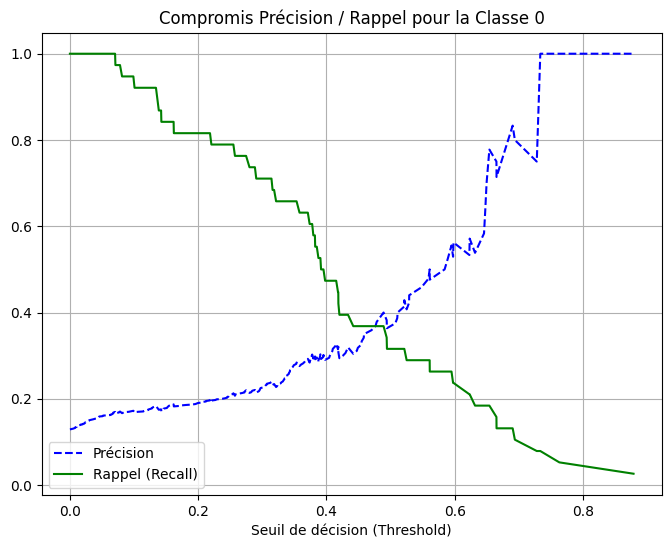

In [ ]:
y_scores = model.predict_proba(X_test)[:, 0]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores, pos_label=0)

plt.figure(figsize=(8, 6))
plt.plot(thresholds, precisions[:-1], "b--", label="Précision")
plt.plot(thresholds, recalls[:-1], "g-", label="Rappel (Recall)")
plt.xlabel("Seuil de décision (Threshold)")
plt.legend(loc="best")
plt.title("Compromis Précision / Rappel pour la Classe 0")
plt.grid()
plt.show()

# **bon en doit faire des corriges pour la phase dentrainement il ya des problemes**

In [8]:
df2=pd.read_csv('/content/drive/MyDrive/python-20260209T035007Z-1-001/python/cleanedDatasetAttrition.csv')
df2.shape

(1470, 9)

In [9]:
df2.head()

,Age,Attrition,BusinessTravel,DistanceFromHome,Education,Gender,MaritalStatus,TotalWorkingYears,TrainingTimesLastYear
0,41,1,2,1,2,0,2,8,0
1,49,0,1,8,1,1,1,10,3
2,37,1,2,2,2,1,2,7,3
3,33,0,1,3,4,0,1,8,3
4,27,0,2,2,1,1,1,6,3


In [ ]:
df2['PerformanceRating'] = df['PerformanceRating'].values

In [ ]:
df2.head()

,Age,Attrition,BusinessTravel,DistanceFromHome,Education,Gender,MaritalStatus,TotalWorkingYears,TrainingTimesLastYear,PerformanceRating
0,41,1,2,1,2,0,2,8,0,3
1,49,0,1,8,1,1,1,10,3,4
2,37,1,2,2,2,1,2,7,3,3
3,33,0,1,3,4,0,1,8,3,3
4,27,0,2,2,1,1,1,6,3,3


In [ ]:
is_top_performer = (df2['PerformanceRating'] > 3)
is_loyal_and_good = (df2['Attrition'] == 0) & (df2['PerformanceRating'] > 3)
df2['Should_hire_New'] = (is_top_performer | is_loyal_and_good).astype(int)

In [ ]:
df2.head()

,Age,Attrition,BusinessTravel,DistanceFromHome,Education,Gender,MaritalStatus,TotalWorkingYears,TrainingTimesLastYear,PerformanceRating,Should_hire_New
0,41,1,2,1,2,0,2,8,0,3,0
1,49,0,1,8,1,1,1,10,3,4,1
2,37,1,2,2,2,1,2,7,3,3,0
3,33,0,1,3,4,0,1,8,3,3,0
4,27,0,2,2,1,1,1,6,3,3,0


In [ ]:
print(df2['Should_hire_New'].value_counts())
df2.drop('PerformanceRating', axis=1, inplace=True)
df2.drop('Attrition', axis=1, inplace=True)

Should_hire_New
0    1244
1     226
Name: count, dtype: int64


In [ ]:
df2.head()

,Age,BusinessTravel,DistanceFromHome,Education,Gender,MaritalStatus,TotalWorkingYears,TrainingTimesLastYear,Should_hire_New
0,41,2,1,2,0,2,8,0,0
1,49,1,8,1,1,1,10,3,1
2,37,2,2,2,1,2,7,3,0
3,33,1,3,4,0,1,8,3,0
4,27,2,2,1,1,1,6,3,0


# **balancing for the new dataset**

# **class weight**

In [ ]:
y = df2['Should_hire_New']
X = df2.drop('Should_hire_New', axis=1)
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced_subsample',
    random_state=42
)

model.fit(X_train2, y_train2)
y_pred2 = model.predict(X_test2)

print("\nRÉSULTATS : RANDOM FOREST (SANS SMOTE, AVEC POIDS)")
print(classification_report(y_test2, y_pred2))


RÉSULTATS : RANDOM FOREST (SANS SMOTE, AVEC POIDS)
              precision    recall  f1-score   support

           0       0.84      0.98      0.91       249
           1       0.00      0.00      0.00        45

    accuracy                           0.83       294
   macro avg       0.42      0.49      0.45       294
weighted avg       0.72      0.83      0.77       294



# **SMOTE**

In [ ]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train2, y_train2)

print(f"Taille avant SMOTE : {y_train2.value_counts().to_dict()}")
print(f"Taille après SMOTE : {y_train_smote.value_counts().to_dict()}")

Taille avant SMOTE : {0: 995, 1: 181}
Taille après SMOTE : {1: 995, 0: 995}

RÉSULTATS APRÈS SMOTE :
              precision    recall  f1-score   support

           0       0.85      0.80      0.82       249
           1       0.15      0.20      0.17        45

    accuracy                           0.71       294
   macro avg       0.50      0.50      0.50       294
weighted avg       0.74      0.71      0.72       294



In [12]:
def details_chaque_modele(X_train, y_train, X_test, y_test):
    modeles = {
        "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
        "SVM (Support Vector)": SVC(class_weight='balanced', probability=True, random_state=42),
        "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
        "Gradient Boosting": GradientBoostingClassifier(random_state=42),
        "KNN (Voisins)": KNeighborsClassifier(n_neighbors=5)
    }

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for nom, modele in modeles.items():
        print(f"\n{'='*40}")
        print(f" ANALYSE DÉTAILLÉE : {nom.upper()}")
        print(f"{'='*40}")

        modele.fit(X_train_scaled, y_train)
        y_pred = modele.predict(X_test_scaled)

        print(classification_report(y_test, y_pred))

        cm = confusion_matrix(y_test, y_pred)
        print(f"Matrice de Confusion (Vrais chiffres) :\n{cm}")
        print(f" -> [Vrais Négatifs, Faux Positifs]")
        print(f" -> [Faux Négatifs, Vrais Positifs]")

#details_chaque_modele(X_train_smote, y_train_smote, X_test2, y_test2)

# **SMOTETomek**

In [ ]:
smote_tomek = SMOTETomek(random_state=42)
X_tomek, y_tomek = smote_tomek.fit_resample(X_train2, y_train2)
details_chaque_modele(X_tomek, y_tomek, X_test2, y_test2)


 ANALYSE DÉTAILLÉE : LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.85      0.69      0.76       249
           1       0.16      0.33      0.22        45

    accuracy                           0.64       294
   macro avg       0.51      0.51      0.49       294
weighted avg       0.75      0.64      0.68       294

Matrice de Confusion (Vrais chiffres) :
[[172  77]
 [ 30  15]]
 -> [Vrais Négatifs, Faux Positifs]
 -> [Faux Négatifs, Vrais Positifs]

 ANALYSE DÉTAILLÉE : SVM (SUPPORT VECTOR)
              precision    recall  f1-score   support

           0       0.86      0.78      0.82       249
           1       0.19      0.29      0.23        45

    accuracy                           0.71       294
   macro avg       0.53      0.54      0.53       294
weighted avg       0.76      0.71      0.73       294

Matrice de Confusion (Vrais chiffres) :
[[195  54]
 [ 32  13]]
 -> [Vrais Négatifs, Faux Positifs]
 -> [Faux Négatifs, Vrais P

# **SMOTEENN**

In [ ]:
smote_enn = SMOTEENN(
    smote=SMOTE(k_neighbors=5, random_state=42),
    enn=EditedNearestNeighbours(n_neighbors=5),   # (3→5→7)
    random_state=42
)
print(f"Taille avant : {y_train.value_counts()}")
X_train_enn, y_train_enn = smote_enn.fit_resample(X_train2, y_train2)
details_chaque_modele(X_train_enn, y_train_enn, X_test2, y_test2)

Taille avant : Should_hire
1    1026
0     150
Name: count, dtype: int64

 ANALYSE DÉTAILLÉE : LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.86      0.72      0.78       249
           1       0.18      0.33      0.23        45

    accuracy                           0.66       294
   macro avg       0.52      0.53      0.51       294
weighted avg       0.75      0.66      0.70       294

Matrice de Confusion (Vrais chiffres) :
[[179  70]
 [ 30  15]]
 -> [Vrais Négatifs, Faux Positifs]
 -> [Faux Négatifs, Vrais Positifs]

 ANALYSE DÉTAILLÉE : SVM (SUPPORT VECTOR)
              precision    recall  f1-score   support

           0       0.86      0.80      0.83       249
           1       0.19      0.27      0.22        45

    accuracy                           0.72       294
   macro avg       0.53      0.53      0.53       294
weighted avg       0.76      0.72      0.74       294

Matrice de Confusion (Vrais chiffres) :
[[199  50]
 [

# **Threshold Tuning**

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test2)

print("Entraînement de la Régression Logistique...")
model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train_smote)

y_proba = model.predict_proba(X_test_scaled)[:, 1]

seuil_choisi = 0.75

y_pred_strict = (y_proba >= seuil_choisi).astype(int)

print(f"\n=== RÉSULTATS AVEC SEUIL STRICT DE {seuil_choisi} ===")
print(classification_report(y_test2, y_pred_strict))

cm = confusion_matrix(y_test2, y_pred_strict)
print("\nMatrice de Confusion :")
print(cm)
print(f"Tu as détecté {cm[1,1]} bons candidats (Vrais Positifs)")
print(f"Tu as fait {cm[0,1]} fausses joies (Faux Positifs)")

Entraînement de la Régression Logistique...

=== RÉSULTATS AVEC SEUIL STRICT DE 0.75 ===
              precision    recall  f1-score   support

           0       0.85      0.96      0.90       249
           1       0.27      0.09      0.13        45

    accuracy                           0.82       294
   macro avg       0.56      0.52      0.52       294
weighted avg       0.76      0.82      0.78       294


Matrice de Confusion :
[[238  11]
 [ 41   4]]
Tu as détecté 4 bons candidats (Vrais Positifs)
Tu as fait 11 fausses joies (Faux Positifs)


# **data training with attrition**

In [ ]:
print(df2["Attrition"].value_counts())

Attrition
0    1233
1     237
Name: count, dtype: int64


In [15]:
y = df2['Attrition']
X = df2.drop('Attrition', axis=1)
X_trainat, X_testat, y_trainat, y_testat = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
details_chaque_modele(X_trainat, y_trainat, X_testat, y_testat)


 ANALYSE DÉTAILLÉE : LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.90      0.59      0.71       247
           1       0.23      0.64      0.34        47

    accuracy                           0.60       294
   macro avg       0.56      0.61      0.52       294
weighted avg       0.79      0.60      0.65       294

Matrice de Confusion (Vrais chiffres) :
[[145 102]
 [ 17  30]]
 -> [Vrais Négatifs, Faux Positifs]
 -> [Faux Négatifs, Vrais Positifs]

 ANALYSE DÉTAILLÉE : SVM (SUPPORT VECTOR)
              precision    recall  f1-score   support

           0       0.89      0.70      0.79       247
           1       0.26      0.55      0.36        47

    accuracy                           0.68       294
   macro avg       0.58      0.63      0.57       294
weighted avg       0.79      0.68      0.72       294

Matrice de Confusion (Vrais chiffres) :
[[174  73]
 [ 21  26]]
 -> [Vrais Négatifs, Faux Positifs]
 -> [Faux Négatifs, Vrais P

In [ ]:
smote = SMOTE(random_state=42)
X_train_smote_at, y_train_smote_at = smote.fit_resample(X_trainat, y_trainat)
details_chaque_modele(X_train_smote_at, y_train_smote_at, X_testat, y_testat)


 ANALYSE DÉTAILLÉE : LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.88      0.68      0.77       247
           1       0.24      0.51      0.32        47

    accuracy                           0.66       294
   macro avg       0.56      0.60      0.55       294
weighted avg       0.78      0.66      0.70       294

Matrice de Confusion (Vrais chiffres) :
[[169  78]
 [ 23  24]]
 -> [Vrais Négatifs, Faux Positifs]
 -> [Faux Négatifs, Vrais Positifs]

 ANALYSE DÉTAILLÉE : SVM (SUPPORT VECTOR)
              precision    recall  f1-score   support

           0       0.86      0.78      0.82       247
           1       0.24      0.36      0.29        47

    accuracy                           0.71       294
   macro avg       0.55      0.57      0.55       294
weighted avg       0.76      0.71      0.73       294

Matrice de Confusion (Vrais chiffres) :
[[192  55]
 [ 30  17]]
 -> [Vrais Négatifs, Faux Positifs]
 -> [Faux Négatifs, Vrais P

In [ ]:
smote_tomek = SMOTETomek(random_state=42)
X_tomek_at, y_tomek_at = smote_tomek.fit_resample(X_trainat, y_trainat)
details_chaque_modele(X_tomek_at, y_tomek_at, X_testat, y_testat)


 ANALYSE DÉTAILLÉE : LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.88      0.68      0.77       247
           1       0.23      0.51      0.32        47

    accuracy                           0.65       294
   macro avg       0.56      0.60      0.54       294
weighted avg       0.78      0.65      0.70       294

Matrice de Confusion (Vrais chiffres) :
[[168  79]
 [ 23  24]]
 -> [Vrais Négatifs, Faux Positifs]
 -> [Faux Négatifs, Vrais Positifs]

 ANALYSE DÉTAILLÉE : SVM (SUPPORT VECTOR)
              precision    recall  f1-score   support

           0       0.86      0.78      0.82       247
           1       0.24      0.36      0.29        47

    accuracy                           0.71       294
   macro avg       0.55      0.57      0.55       294
weighted avg       0.76      0.71      0.73       294

Matrice de Confusion (Vrais chiffres) :
[[192  55]
 [ 30  17]]
 -> [Vrais Négatifs, Faux Positifs]
 -> [Faux Négatifs, Vrais P

# **cycle R&D**

# **Hyperparameter Tuning avec GridSearchCV + StratifiedKFold**

In [52]:
y = df2['Attrition']
X = df2.drop('Attrition', axis=1)
#print(X)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
print(f"scale_pos_weight calculé : {scale_pos_weight:.2f}")

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    # ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('model', XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        use_label_encoder=False
    ))
])

param_grid = {
    'model__n_estimators': [50,100],
    'model__max_depth': [2,4],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.5, 0.8],
    'model__colsample_bytree': [0.8, 1.0],
    'model__scale_pos_weight': [scale_pos_weight, scale_pos_weight * 0.8, scale_pos_weight * 1.2]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

print("Lancement du GridSearchCV \n")
grid_search.fit(X_train, y_train)

print("\n" + "="*60)
print("MEILLEURS PARAMÈTRES TROUVÉS")
print("="*60)
print(grid_search.best_params_)
print(f"\nMeilleur score F1 Macro en CV : {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("\n" + "="*60)
print("RAPPORT FINAL SUR LE TEST SET")
print("="*60)
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
print(f"\nMatrice de Confusion :\n{cm}")
print(" → [Vrais Négatifs, Faux Positifs]")
print(" → [Faux Négatifs, Vrais Positifs]")

      Age  BusinessTravel  DistanceFromHome  Education  Gender  MaritalStatus  \
0      41               2                 1          2       0              2   
1      49               1                 8          1       1              1   
2      37               2                 2          2       1              2   
3      33               1                 3          4       0              1   
4      27               2                 2          1       1              1   
...   ...             ...               ...        ...     ...            ...   
1465   36               1                23          2       1              1   
1466   39               2                 6          1       1              1   
1467   27               2                 4          3       1              1   
1468   49               1                 2          3       1              1   
1469   34               2                 8          3       1              1   

      TotalWorkingYears  Tr

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [22:48:09] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



MEILLEURS PARAMÈTRES TROUVÉS
{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.01, 'model__max_depth': 2, 'model__n_estimators': 100, 'model__scale_pos_weight': 4.151578947368421, 'model__subsample': 0.5}

Meilleur score F1 Macro en CV : 0.6391

RAPPORT FINAL SUR LE TEST SET
              precision    recall  f1-score   support

           0     0.8571    0.8745    0.8657       247
           1     0.2619    0.2340    0.2472        47

    accuracy                         0.7721       294
   macro avg     0.5595    0.5543    0.5565       294
weighted avg     0.7620    0.7721    0.7668       294


Matrice de Confusion :
[[216  31]
 [ 36  11]]
 → [Vrais Négatifs, Faux Positifs]
 → [Faux Négatifs, Vrais Positifs]


# **SMOTE + Voting + XGBoost**

In [55]:
def analyse_avancee(X, y):
    clf1 = LogisticRegression(random_state=42, max_iter=1000)

    clf2 = RandomForestClassifier(n_estimators=200, min_samples_leaf=2, random_state=42)

    ratio = float(np.sum(y == 0)) / np.sum(y == 1)
    clf3 = XGBClassifier(scale_pos_weight=ratio, eval_metric='logloss', use_label_encoder=False, random_state=42)

    voting_clf = VotingClassifier(
        estimators=[('lr', clf1), ('rf', clf2), ('xgb', clf3)],
        voting='soft',
        weights=[1, 2, 3]
    )
    model_pipeline = ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42, sampling_strategy=0.5)),
        ('model', voting_clf)
    ])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    print(" Démarrage de la Cross-Validation (F1-Score)...")

    scores = cross_val_score(model_pipeline, X, y, scoring='f1', cv=cv)
    print(f"F1-Score Moyen sur 5 folds : {scores.mean():.4f} (+/- {scores.std():.4f})")
    print(f"Accuracy Moyenne : {cross_val_score(model_pipeline, X, y, scoring='accuracy', cv=cv).mean():.4f}")

    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

    model_pipeline.fit(X_train, y_train)
    y_pred = model_pipeline.predict(X_test)

    print("\n" + "="*40)
    print(" RÉSULTATS DU VOTING CLASSIFIER (SMOTE + XGB)")
    print("="*40)
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    print(f"Matrice de Confusion :\n{cm}")
analyse_avancee(X, y)

 Démarrage de la Cross-Validation (F1-Score)...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [22:49:54] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [22:49:55] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [22:49:56] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [22:49:58] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [22:49:59] WARNING: /w

F1-Score Moyen sur 5 folds : 0.2995 (+/- 0.0221)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [22:49:59] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [22:50:00] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [22:50:01] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [22:50:01] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [22:50:02] WARNING: /w

Accuracy Moyenne : 0.7959

 RÉSULTATS DU VOTING CLASSIFIER (SMOTE + XGB)
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       247
           1       0.23      0.17      0.20        47

    accuracy                           0.78       294
   macro avg       0.54      0.53      0.53       294
weighted avg       0.75      0.78      0.76       294

Matrice de Confusion :
[[220  27]
 [ 39   8]]


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [22:50:03] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


# **ADASYN + Random Forest (avec GridSearchCV)**

In [56]:
ipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('adasyn', ADASYN(random_state=42, n_neighbors=5)),
    ('model', RandomForestClassifier(
        random_state=42,
        class_weight='balanced'
    ))
])

param_grid = {
    'model__n_estimators': [100, 200, ],
    'model__max_depth': [None, 15, 20],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2],
    'model__max_features': ['sqrt', 'log2']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

print("Lancement du GridSearchCV avec ADASYN + Random Forest...\n")
grid_search.fit(X_train, y_train)

print("\n" + "="*70)
print("MEILLEURS PARAMÈTRES")
print("="*70)
print(grid_search.best_params_)
print(f"\nMeilleur F1 Macro en CV : {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("\n" + "="*70)
print("RAPPORT FINAL SUR LE TEST SET")
print("="*70)
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
print(f"\nMatrice de Confusion :\n{cm}")
print(" → [Vrais Négatifs , Faux Positifs]")
print(" → [Faux Négatifs  , Vrais Positifs]")

Lancement du GridSearchCV avec ADASYN + Random Forest...

Fitting 5 folds for each of 48 candidates, totalling 240 fits

MEILLEURS PARAMÈTRES
{'model__max_depth': 15, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}

Meilleur F1 Macro en CV : 0.6100

RAPPORT FINAL SUR LE TEST SET
              precision    recall  f1-score   support

           0     0.8504    0.9433    0.8944       247
           1     0.3000    0.1277    0.1791        47

    accuracy                         0.8129       294
   macro avg     0.5752    0.5355    0.5368       294
weighted avg     0.7624    0.8129    0.7801       294


Matrice de Confusion :
[[233  14]
 [ 41   6]]
 → [Vrais Négatifs , Faux Positifs]
 → [Faux Négatifs  , Vrais Positifs]


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [22:50:29] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "max_features", "min_samples_leaf", "min_samples_split", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


# **amelioration de random forest**

# **Optimisation du class_weight**

In [57]:
def rf_class_weight_optimise(X_train, y_train, X_test, y_test):

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    n_classe_0 = np.sum(y_train == 0)
    n_classe_1 = np.sum(y_train == 1)
    ratio = n_classe_0 / n_classe_1

    print(f"\n Distribution des classes:")
    print(f"   Classe 0: {n_classe_0}")
    print(f"   Classe 1: {n_classe_1}")
    print(f"   Ratio: {ratio:.2f}:1")

    class_weights_a_tester = [
        'balanced',
        {0: 1, 1: ratio},
        {0: 1, 1: ratio * 0.7},
        {0: 1, 1: ratio * 1.3},
        {0: 1, 1: ratio * 1.5},
        {0: 1, 1: ratio * 2.0},
        {0: 1, 1: 10},
        {0: 1, 1: 15},
    ]

    resultats = []

    for i, cw in enumerate(class_weights_a_tester):
        print(f"\n--- Test {i+1}/{len(class_weights_a_tester)}: class_weight = {cw} ---")

        rf = RandomForestClassifier(
            n_estimators=200,
            max_depth=20,
            min_samples_split=5,
            min_samples_leaf=2,
            class_weight=cw,
            random_state=42,
            n_jobs=-1
        )

        rf.fit(X_train_scaled, y_train)
        y_pred = rf.predict(X_test_scaled)

        report = classification_report(y_test, y_pred, output_dict=True)

        resultats.append({
            'class_weight': str(cw),
            'F1_Classe_1': report['1']['f1-score'],
            'Recall_Classe_1': report['1']['recall'],
            'Precision_Classe_1': report['1']['precision'],
            'Accuracy': report['accuracy']
        })

        print(f"F1 classe 1: {report['1']['f1-score']:.4f}")
        print(f"Recall classe 1: {report['1']['recall']:.4f}")
        print(f"Precision classe 1: {report['1']['precision']:.4f}")
    df_resultats = pd.DataFrame(resultats).sort_values('F1_Classe_1', ascending=False)

    print("\n\n CLASSEMENT DES class_weight:")
    print(df_resultats.to_string(index=False))
    meilleur_cw = eval(df_resultats.iloc[0]['class_weight'])

    print(f"\n MEILLEUR class_weight: {meilleur_cw}")
    print(f"   F1-Score: {df_resultats.iloc[0]['F1_Classe_1']:.4f}")
    rf_best = RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight=meilleur_cw,
        random_state=42,
        n_jobs=-1
    )
    rf_best.fit(X_train_scaled, y_train)

    return rf_best, scaler, meilleur_cw
rf_class_weight_optimise(X_train, y_train, X_test, y_test)


 Distribution des classes:
   Classe 0: 986
   Classe 1: 190
   Ratio: 5.19:1

--- Test 1/8: class_weight = balanced ---
F1 classe 1: 0.1739
Recall classe 1: 0.1277
Precision classe 1: 0.2727

--- Test 2/8: class_weight = {0: 1, 1: np.float64(5.189473684210526)} ---
F1 classe 1: 0.1739
Recall classe 1: 0.1277
Precision classe 1: 0.2727

--- Test 3/8: class_weight = {0: 1, 1: np.float64(3.6326315789473678)} ---
F1 classe 1: 0.1791
Recall classe 1: 0.1277
Precision classe 1: 0.3000

--- Test 4/8: class_weight = {0: 1, 1: np.float64(6.746315789473684)} ---
F1 classe 1: 0.1690
Recall classe 1: 0.1277
Precision classe 1: 0.2500

--- Test 5/8: class_weight = {0: 1, 1: np.float64(7.784210526315789)} ---
F1 classe 1: 0.1667
Recall classe 1: 0.1277
Precision classe 1: 0.2400

--- Test 6/8: class_weight = {0: 1, 1: np.float64(10.378947368421052)} ---
F1 classe 1: 0.1892
Recall classe 1: 0.1489
Precision classe 1: 0.2593

--- Test 7/8: class_weight = {0: 1, 1: 10} ---
F1 classe 1: 0.2105
Recall 

(RandomForestClassifier(class_weight={0: 1, 1: 10}, max_depth=20,
                        min_samples_leaf=2, min_samples_split=5,
                        n_estimators=200, n_jobs=-1, random_state=42),
 StandardScaler(),
 {0: 1, 1: 10})

# **Optimisation complète des hyperparamètres**

In [58]:
def rf_hyperparametres_optimises(X_train, y_train, X_test, y_test, methode='random'):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    param_grid = {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [10, 15, 20, 25, 30, None],
        'min_samples_split': [2, 5, 10, 15],
        'min_samples_leaf': [1, 2, 4, 6],
        'max_features': ['sqrt', 'log2', 0.3, 0.5],
        'class_weight': ['balanced', 'balanced_subsample'],
        'max_samples': [0.7, 0.8, 0.9, None],
        'criterion': ['gini', 'entropy']
    }

    f1_scorer = make_scorer(f1_score, pos_label=1)

    rf = RandomForestClassifier(random_state=42, n_jobs=-1)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    if methode == 'grid':
        print("\n GridSearchCV en cours (peut prendre 15-30 min)...")
        search = GridSearchCV(
            rf,
            param_grid,
            cv=cv,
            scoring=f1_scorer,
            n_jobs=-1,
            verbose=2
        )
    else:
        print("\n RandomizedSearchCV en cours (plus rapide)...")
        search = RandomizedSearchCV(
            rf,
            param_grid,
            n_iter=50,
            cv=cv,
            scoring=f1_scorer,
            n_jobs=-1,
            verbose=2,
            random_state=42
        )

    search.fit(X_train_scaled, y_train)

    best_rf = search.best_estimator_

    print(f"\n MEILLEURS HYPERPARAMÈTRES:")
    for param, value in search.best_params_.items():
        print(f"   {param}: {value}")

    print(f"\n Meilleur F1-score (CV): {search.best_score_:.4f}")

    y_pred = best_rf.predict(X_test_scaled)
    y_proba = best_rf.predict_proba(X_test_scaled)[:, 1]

    print("\n Performance sur ensemble de test:")
    print(classification_report(y_test, y_pred, target_names=['Pas Attrition', 'Attrition']))
    print(f"\nMatrice de Confusion:\n{confusion_matrix(y_test, y_pred)}")
    print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

    return best_rf, scaler, search
rf_hyperparametres_optimises(X_train, y_train, X_test, y_test, methode='random')


 RandomizedSearchCV en cours (plus rapide)...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

 MEILLEURS HYPERPARAMÈTRES:
   n_estimators: 500
   min_samples_split: 10
   min_samples_leaf: 6
   max_samples: 0.9
   max_features: 0.3
   max_depth: 20
   criterion: gini
   class_weight: balanced

 Meilleur F1-score (CV): 0.3707

 Performance sur ensemble de test:
               precision    recall  f1-score   support

Pas Attrition       0.86      0.85      0.85       247
    Attrition       0.24      0.26      0.25        47

     accuracy                           0.75       294
    macro avg       0.55      0.55      0.55       294
 weighted avg       0.76      0.75      0.75       294


Matrice de Confusion:
[[209  38]
 [ 35  12]]
ROC-AUC: 0.6430


(RandomForestClassifier(class_weight='balanced', max_depth=20, max_features=0.3,
                        max_samples=0.9, min_samples_leaf=6,
                        min_samples_split=10, n_estimators=500, n_jobs=-1,
                        random_state=42),
 StandardScaler(),
 RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                    estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
                    n_iter=50, n_jobs=-1,
                    param_distributions={'class_weight': ['balanced',
                                                          'balanced_subsample'],
                                         'criterion': ['gini', 'entropy'],
                                         'max_depth': [10, 15, 20, 25, 30, None],
                                         'max_features': ['sqrt', 'log2', 0.3,
                                                          0.5],
                                         'max_samples': [0.7, 0.

# **Balanced Random Forest(imblearn)**

In [59]:
def balanced_random_forest_optimise(X_train, y_train, X_test, y_test):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [15, 20, 25, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2'],
        'sampling_strategy': ['auto', 'all', 'not minority'],
        'replacement': [True, False]
    }

    brf = BalancedRandomForestClassifier(random_state=42, n_jobs=-1)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    f1_scorer = make_scorer(f1_score, pos_label=1)

    print("\n Optimisation Balanced RF...")
    search = RandomizedSearchCV(
        brf,
        param_grid,
        n_iter=30,
        cv=cv,
        scoring=f1_scorer,
        n_jobs=-1,
        verbose=1,
        random_state=42
    )

    search.fit(X_train_scaled, y_train)

    best_brf = search.best_estimator_

    print(f"\n MEILLEURS HYPERPARAMÈTRES:")
    for param, value in search.best_params_.items():
        print(f"   {param}: {value}")

    print(f"\n Meilleur F1-score (CV): {search.best_score_:.4f}")
    y_pred = best_brf.predict(X_test_scaled)
    y_proba = best_brf.predict_proba(X_test_scaled)[:, 1]

    print("\n Performance sur ensemble de test:")
    print(classification_report(y_test, y_pred, target_names=['Pas Attrition', 'Attrition']))
    print(f"\nMatrice de Confusion:\n{confusion_matrix(y_test, y_pred)}")
    print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

    return best_brf, scaler, search
balanced_random_forest_optimise(X_train, y_train, X_test, y_test)


 Optimisation Balanced RF...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

 MEILLEURS HYPERPARAMÈTRES:
   sampling_strategy: auto
   replacement: False
   n_estimators: 100
   min_samples_split: 10
   min_samples_leaf: 1
   max_features: sqrt
   max_depth: 20

 Meilleur F1-score (CV): 0.3563

 Performance sur ensemble de test:
               precision    recall  f1-score   support

Pas Attrition       0.89      0.66      0.75       247
    Attrition       0.23      0.55      0.33        47

     accuracy                           0.64       294
    macro avg       0.56      0.60      0.54       294
 weighted avg       0.78      0.64      0.69       294


Matrice de Confusion:
[[162  85]
 [ 21  26]]
ROC-AUC: 0.6461


(BalancedRandomForestClassifier(max_depth=20, min_samples_split=10, n_jobs=-1,
                                random_state=42, replacement=False,
                                sampling_strategy='auto'),
 StandardScaler(),
 RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                    estimator=BalancedRandomForestClassifier(n_jobs=-1,
                                                             random_state=42),
                    n_iter=30, n_jobs=-1,
                    param_distributions={'max_depth': [15, 20, 25, 30],
                                         'max_features': ['sqrt', 'log2'],
                                         'min_samples_leaf': [1, 2, 4],
                                         'min_samples_split': [2, 5, 10],
                                         'n_estimators': [100, 200, 300],
                                         'replacement': [True, False],
                                         'sampling_strategy':

In [61]:
print(X_train)
print(y_train)

      Age  BusinessTravel  DistanceFromHome  Education  Gender  MaritalStatus  \
1194   47               2                 2          4       0              0   
128    22               2                 2          1       1              1   
810    46               2                 3          1       1              1   
478    25               2                13          1       1              1   
491    43               1                 9          5       1              0   
...   ...             ...               ...        ...     ...            ...   
1213   23               2                 7          3       1              0   
963    38               2                 2          2       0              0   
734    22               2                 8          1       1              1   
1315   36               2                 2          4       0              1   
1292   39               1                20          3       1              0   

      TotalWorkingYears  Tr

# **Ajustement du seuil de classification**

In [62]:
def rf_ajustement_seuil(modele, scaler, X_test, y_test, objectif='f1'):

    X_test_scaled = scaler.transform(X_test)
    y_proba = modele.predict_proba(X_test_scaled)[:, 1]

    seuils = np.arange(0.05, 0.95, 0.02)
    resultats = []

    for seuil in seuils:
        y_pred = (y_proba >= seuil).astype(int)

        try:
            f1 = f1_score(y_test, y_pred)
            recall = recall_score(y_test, y_pred)
            precision = precision_score(y_test, y_pred)
        except:
            f1 = 0
            recall = 0
            precision = 0

        resultats.append({
            'Seuil': seuil,
            'F1': f1,
            'Recall': recall,
            'Precision': precision
        })

    df_seuils = pd.DataFrame(resultats)
    if objectif == 'f1':
        meilleur_idx = df_seuils['F1'].idxmax()
        metrique = 'F1'
    elif objectif == 'recall':
        meilleur_idx = df_seuils['Recall'].idxmax()
        metrique = 'Recall'
    else:
        meilleur_idx = df_seuils['Precision'].idxmax()
        metrique = 'Precision'

    meilleur_seuil = df_seuils.loc[meilleur_idx, 'Seuil']
    y_pred_default = (y_proba >= 0.5).astype(int)
    y_pred_optimal = (y_proba >= meilleur_seuil).astype(int)

    print(f"\n SEUIL PAR DÉFAUT (0.50):")
    print(classification_report(y_test, y_pred_default, target_names=['Pas Attrition', 'Attrition']))

    print(f"\n SEUIL OPTIMAL ({meilleur_seuil:.2f}) pour maximiser {metrique}:")
    print(classification_report(y_test, y_pred_optimal, target_names=['Pas Attrition', 'Attrition']))

    print(f"\n Exemples de seuils et leurs impacts:")
    exemples = df_seuils[df_seuils['Seuil'].isin([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7])]
    print(exemples.to_string(index=False))
    f1_default = f1_score(y_test, y_pred_default)
    f1_optimal = f1_score(y_test, y_pred_optimal)

    print(f"\nAMÉLIORATION:")
    print(f"   F1-Score: {f1_default:.4f} → {f1_optimal:.4f} (+{((f1_optimal-f1_default)/f1_default*100):.1f}%)")

    return meilleur_seuil, y_pred_optimal, df_seuils
brf, scaler, search = balanced_random_forest_optimise(X_train, y_train, X_test, y_test)
seuil, y_pred_optimal, df_seuils = rf_ajustement_seuil(brf, scaler, X_test, y_test)


 Optimisation Balanced RF...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

 MEILLEURS HYPERPARAMÈTRES:
   sampling_strategy: auto
   replacement: False
   n_estimators: 100
   min_samples_split: 10
   min_samples_leaf: 1
   max_features: sqrt
   max_depth: 20

 Meilleur F1-score (CV): 0.3563

 Performance sur ensemble de test:
               precision    recall  f1-score   support

Pas Attrition       0.89      0.66      0.75       247
    Attrition       0.23      0.55      0.33        47

     accuracy                           0.64       294
    macro avg       0.56      0.60      0.54       294
 weighted avg       0.78      0.64      0.69       294


Matrice de Confusion:
[[162  85]
 [ 21  26]]
ROC-AUC: 0.6461

 SEUIL PAR DÉFAUT (0.50):
               precision    recall  f1-score   support

Pas Attrition       0.89      0.66      0.75       247
    Attrition       0.23      0.55      0.33        47

     accuracy                           0.64       294
    macro

# **ENSEMBLE DE RANDOM FORESTS (Bagging custom)**

In [63]:
def rf_bagging_custom(X_train, y_train, X_test, y_test):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    ratio = np.sum(y_train == 0) / np.sum(y_train == 1)

    rf_configs = [
        {
            'name': 'RF_Balanced',
            'model': RandomForestClassifier(
                n_estimators=200,
                max_depth=20,
                class_weight='balanced',
                random_state=42,
                n_jobs=-1
            )
        },
        {
            'name': 'RF_Aggressive',
            'model': RandomForestClassifier(
                n_estimators=200,
                max_depth=25,
                class_weight={0: 1, 1: ratio * 2},
                random_state=43,
                n_jobs=-1
            )
        },
        {
            'name': 'RF_Deep',
            'model': RandomForestClassifier(
                n_estimators=300,
                max_depth=None,
                min_samples_split=2,
                class_weight='balanced_subsample',
                random_state=44,
                n_jobs=-1
            )
        }
    ]

    modeles_entraines = []
    predictions = []

    for config in rf_configs:
        print(f"\n Entraînement: {config['name']}")
        model = config['model']
        model.fit(X_train_scaled, y_train)
        modeles_entraines.append(model)

        y_proba = model.predict_proba(X_test_scaled)[:, 1]
        predictions.append(y_proba)

    y_proba_ensemble = np.mean(predictions, axis=0)
    seuils = np.arange(0.1, 0.9, 0.02)
    meilleur_f1 = 0
    meilleur_seuil = 0.5

    for seuil in seuils:
        y_pred = (y_proba_ensemble >= seuil).astype(int)
        f1 = f1_score(y_test, y_pred)
        if f1 > meilleur_f1:
            meilleur_f1 = f1
            meilleur_seuil = seuil

    y_pred_ensemble = (y_proba_ensemble >= meilleur_seuil).astype(int)

    print(f"\n RÉSULTATS DE L'ENSEMBLE (seuil={meilleur_seuil:.2f}):")
    print(classification_report(y_test, y_pred_ensemble, target_names=['Pas Attrition', 'Attrition']))
    print(f"\nMatrice de Confusion:\n{confusion_matrix(y_test, y_pred_ensemble)}")
    print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_ensemble):.4f}")

    return modeles_entraines, scaler, meilleur_seuil
rf_bagging_custom(X_train, y_train, X_test, y_test)


 Entraînement: RF_Balanced

 Entraînement: RF_Aggressive

 Entraînement: RF_Deep

 RÉSULTATS DE L'ENSEMBLE (seuil=0.14):
               precision    recall  f1-score   support

Pas Attrition       0.88      0.58      0.70       247
    Attrition       0.21      0.60      0.31        47

     accuracy                           0.58       294
    macro avg       0.55      0.59      0.51       294
 weighted avg       0.78      0.58      0.64       294


Matrice de Confusion:
[[143 104]
 [ 19  28]]
ROC-AUC: 0.6177


([RandomForestClassifier(class_weight='balanced', max_depth=20, n_estimators=200,
                         n_jobs=-1, random_state=42),
  RandomForestClassifier(class_weight={0: 1, 1: np.float64(10.378947368421052)},
                         max_depth=25, n_estimators=200, n_jobs=-1,
                         random_state=43),
  RandomForestClassifier(class_weight='balanced_subsample', n_estimators=300,
                         n_jobs=-1, random_state=44)],
 StandardScaler(),
 np.float64(0.14))

In [16]:
y = df2['Attrition']
X = df2.drop('Attrition', axis=1)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

model=RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("\nRÉSULTATS : RANDOM FOREST (SANS SMOTE, AVEC POIDS)")
print(classification_report(y_test, y_pred))


RÉSULTATS : RANDOM FOREST (SANS SMOTE, AVEC POIDS)
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.50      0.11      0.18        47

    accuracy                           0.84       294
   macro avg       0.68      0.54      0.54       294
weighted avg       0.80      0.84      0.79       294



In [1]:
pip install aif360

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 6.2 MB/s eta 0:00:00


# **Reweighing for MaritalStatus**

In [38]:
X = df2.drop('Attrition', axis=1)
y = df2['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

protected_attribute = 'MaritalStatus'
privileged_groups = [{protected_attribute: 1}]
unprivileged_groups = [{protected_attribute: 2}]
dataset_train = BinaryLabelDataset(
    df=pd.concat([X_train, y_train], axis=1),
    label_names=['Attrition'],
    protected_attribute_names=[protected_attribute],
    favorable_label=1,
    unfavorable_label=0
)

rw = Reweighing(unprivileged_groups=unprivileged_groups,
                privileged_groups=privileged_groups)
dataset_train_weighted = rw.fit_transform(dataset_train)
sample_weights = dataset_train_weighted.instance_weights


model = RandomForestClassifier(
    class_weight='balanced_subsample',
    random_state=42,
    n_estimators=53,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5
)
model.fit(X_train_scaled, y_train, sample_weight=sample_weights)

y_pred = model.predict(X_test_scaled)


acc = accuracy_score(y_test, y_pred)
print(f"Accuracy : {acc:.4f}")

dataset_test = BinaryLabelDataset(
    df=pd.concat([X_test, y_test], axis=1),
    label_names=['Attrition'],
    protected_attribute_names=[protected_attribute],
    favorable_label=1,
    unfavorable_label=0
)

df_test_pred = X_test.copy()
df_test_pred['Attrition'] = y_pred
dataset_pred = BinaryLabelDataset(
    df=df_test_pred,
    label_names=['Attrition'],
    protected_attribute_names=[protected_attribute],
    favorable_label=1,
    unfavorable_label=0
)

metric = ClassificationMetric(
    dataset_test,
    dataset_pred,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("\n--- Équité du modèle ---")
print(f"Disparate Impact (prédictions)      : {metric.disparate_impact():.4f}")
print(f"Statistical Parity Difference       : {metric.statistical_parity_difference():.4f}")

Accuracy : 0.7846

--- Équité du modèle ---
Disparate Impact (prédictions)      : 1.0292
Statistical Parity Difference       : 0.0045


# **for sex**

In [53]:
X = df2.drop('Attrition', axis=1)
y = df2['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

protected_attribute = 'Gender'
privileged_groups = [{protected_attribute: 1}]   # homme
unprivileged_groups = [{protected_attribute: 0}] # femme
dataset_train = BinaryLabelDataset(
    df=pd.concat([X_train, y_train], axis=1),
    label_names=['Attrition'],
    protected_attribute_names=[protected_attribute],
    favorable_label=1,
    unfavorable_label=0
)

rw = Reweighing(unprivileged_groups=unprivileged_groups,
                privileged_groups=privileged_groups)
dataset_train_weighted = rw.fit_transform(dataset_train)
sample_weights = dataset_train_weighted.instance_weights


model = RandomForestClassifier(
    class_weight='balanced_subsample',
    random_state=42,
    n_estimators=70,
    max_depth=2,
    min_samples_split=5,
    min_samples_leaf=15
)
model.fit(X_train_scaled, y_train, sample_weight=sample_weights)

y_pred = model.predict(X_test_scaled)


acc = accuracy_score(y_test, y_pred)
print(f"Accuracy : {acc:.4f}")

dataset_test = BinaryLabelDataset(
    df=pd.concat([X_test, y_test], axis=1),
    label_names=['Attrition'],
    protected_attribute_names=[protected_attribute],
    favorable_label=1,
    unfavorable_label=0
)

df_test_pred = X_test.copy()
df_test_pred['Attrition'] = y_pred
dataset_pred = BinaryLabelDataset(
    df=df_test_pred,
    label_names=['Attrition'],
    protected_attribute_names=[protected_attribute],
    favorable_label=1,
    unfavorable_label=0
)

metric = ClassificationMetric(
    dataset_test,
    dataset_pred,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("\n--- Équité du modèle ---")
print(f"Disparate Impact (prédictions)      : {metric.disparate_impact():.4f}")
print(f"Statistical Parity Difference       : {metric.statistical_parity_difference():.4f}")

Accuracy : 0.7143

--- Équité du modèle ---
Disparate Impact (prédictions)      : 1.2017
Statistical Parity Difference       : 0.0556
